In [1]:
import mlflow
import pandas as pd
import numpy as np



/home/bashar/anaconda3/envs/mlops/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd
df = pd.read_csv("hf://datasets/AmaanP314/youtube-comment-sentiment/youtube-comments-sentiment.csv")


In [3]:
df = df[['CommentText','Sentiment']]
sentiment_dict = {'Neutral':0, 'Positive': 1, 'Negative': -1}
df['Sentiment'] = df['Sentiment'].apply(lambda x: sentiment_dict[x])



In [4]:
import nltk
import re
from nltk.corpus import stopwords
from nltk import WordNetLemmatizer

In [5]:
def preprocess(comment):
    """Accept a comment column, and perform preprcoessing on it
    """
    comment = comment.lower()
    comment = comment.strip()
    comment = comment.replace('\n',' ')
    comment = re.sub(r'[^A-Za-z0-9\s!?.,]','', comment)    
    stop_words = set(stopwords.words('english')) - {'but','not','however','no','yet'}
    comment = ' '.join([word for word in comment.split() if word not in stop_words])
    lemmatizer = WordNetLemmatizer()
    comment = ' '.join([lemmatizer.lemmatize(word) for word in comment.split()])

    return comment
    

In [ ]:
df['CommentText'] = df['CommentText'].apply(lambda x: preprocess(x))

In [39]:
df.dropna(inplace=True)
df.to_csv('data/df_preprocessed.csv', index=False)

In [41]:
df['CommentText']

0                                      anyone know movie is?
1                fact theyre holding back equally aggressive
2                                     waiting next video be?
3          thanks great video. dont understand db continu...
4          good person helping good people. america excep...
                                 ...                        
1032220    recommendation build top this? add complexity,...
1032221              act foolishly, receive foolish rewards.
1032222    think many people would like know model black ...
1032223                                              caramel
1032224                                             no rust?
Name: CommentText, Length: 1008281, dtype: object

In [42]:
### Build the baseline

In [3]:
import mlflow
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path

/home/bashar/anaconda3/envs/mlops/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df_path = Path('data/df_preprocessed.csv')
if df_path.exists():
    df = pd.read_csv(df_path)
else:
    print(f"No such file : {df_path}")

In [5]:
sum(df['CommentText'].isna())

0

In [ ]:
vectorizer = CountVectorizer(max_features=10)
X = vectorizer.fit_transform(df['CommentText']).toarray()

In [73]:
y = df['Sentiment']

In [83]:
X_train,X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

🏃 View run gifted-bat-756 at: http://localhost:5000/#/experiments/3/runs/08b5e3de6c224338bcba20a954df8023
🧪 View experiment at: http://localhost:5000/#/experiments/3
acc=0.40231747028778286


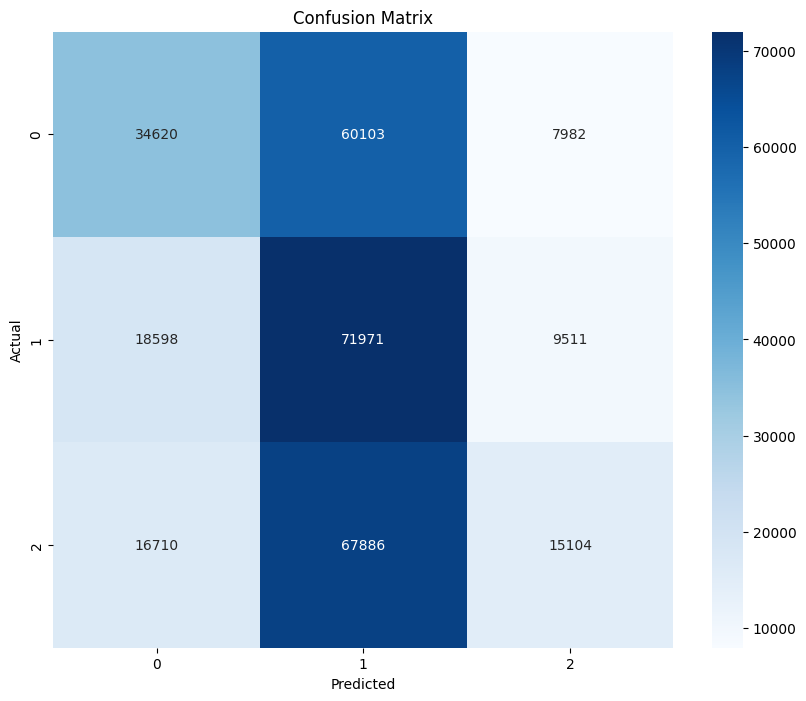

In [107]:
mlflow.set_experiment('YT Sentiment Baseline')
mlflow.set_tracking_uri('http://localhost:5000')

hyperparams = {
    'n_estimators': 10,
    'max_depth': 15,
    'random_state': 42,
    'criterion':'gini',
}


with mlflow.start_run() as run:
    mlflow.set_tag('Baseline','RandomForestClassifier')
    mlflow.log_params(hyperparams)

    model = RandomForestClassifier(**hyperparams)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cls_rep = classification_report(y_test, y_pred, output_dict=True)
    for label, metrics in cls_rep.items():
        if isinstance(metrics, dict):
            for metric, value in metrics.items():
                mlflow.log_metric(f"{label}_{metric}", value)

    cf = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10,8))
    sns.heatmap(cf, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig('Confusion_matrix.png')
    mlflow.log_artifact('Confusion_matrix.png')
    
    mlflow.log_metric("accuracy",acc)

print(f"{acc=}")



In [1]:
### Experiment 2: BoW vs TFIDF vectorizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import mlflow
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path



/home/bashar/anaconda3/envs/mlops/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
def run_experiment(experiment_name, vectorization_method:str, n_gram_range:tuple, max_features:int = 1000):
    mlflow.set_experiment(experiment_name)
    
    if vectorization_method == 'BoW':
        vectorizer = CountVectorizer(ngram_range=n_gram_range, max_features=max_features)
    elif vectorization_method == 'TFIDF':
        vectorizer = TfidfVectorizer(ngram_range=n_gram_range, max_features=max_features)
    else:
        raise Exception(f"Vectorization method name is invalid")
    X = vectorizer.fit_transform(df['CommentText']).toarray()
    y = df['Sentiment']

    X_train,X_test, y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)
    hyperparams = {
    'n_estimators': 100,
    'max_depth': 15,
    'random_state': 42,
    }
    with mlflow.start_run() as run:
        mlflow.set_tag('Baseline','RandomForestClassifier')
        mlflow.set_tag('Vectorizer', vectorization_method)
        mlflow.log_params(hyperparams)
        mlflow.log_param('ngram_range', n_gram_range)
        mlflow.log_param('vectorizer',vectorization_method)
        mlflow.log_param('max_features',max_features)

        model = RandomForestClassifier(**hyperparams)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        cls_rep = classification_report(y_test, y_pred, output_dict=True)
        for label, metrics in cls_rep.items():
            if isinstance(metrics, dict):
                for metric, value in metrics.items():
                    mlflow.log_metric(f"{label}_{metric}", value)

        cf = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(10,8))
        sns.heatmap(cf, annot=True, fmt='d', cmap='Blues')
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.savefig('Confusion_matrix.png')
        mlflow.log_artifact('Confusion_matrix.png')
        
        mlflow.log_metric("accuracy",acc)
    del model

    print(f"{acc=}")

🏃 View run merciful-horse-956 at: http://localhost:5000/#/experiments/5/runs/11c0952fe9574e19a896d13875ea0d05
🧪 View experiment at: http://localhost:5000/#/experiments/5
acc=0.40336313641480337
🏃 View run sincere-sponge-351 at: http://localhost:5000/#/experiments/5/runs/e8b4204c90fb44e399a16cc67968c339
🧪 View experiment at: http://localhost:5000/#/experiments/5
acc=0.40328875268401293
🏃 View run treasured-squid-931 at: http://localhost:5000/#/experiments/5/runs/821a6d9fa03140ccbf367f767922e95e
🧪 View experiment at: http://localhost:5000/#/experiments/5
acc=0.40336313641480337
🏃 View run gentle-hog-78 at: http://localhost:5000/#/experiments/5/runs/524311f1cb344a4998167bb76dbb87c3
🧪 View experiment at: http://localhost:5000/#/experiments/5
acc=0.40328875268401293
🏃 View run dazzling-worm-74 at: http://localhost:5000/#/experiments/5/runs/33fd5c39e30f4a8b99ac58913d32231e
🧪 View experiment at: http://localhost:5000/#/experiments/5
acc=0.40336313641480337
🏃 View run skittish-turtle-172 at: h

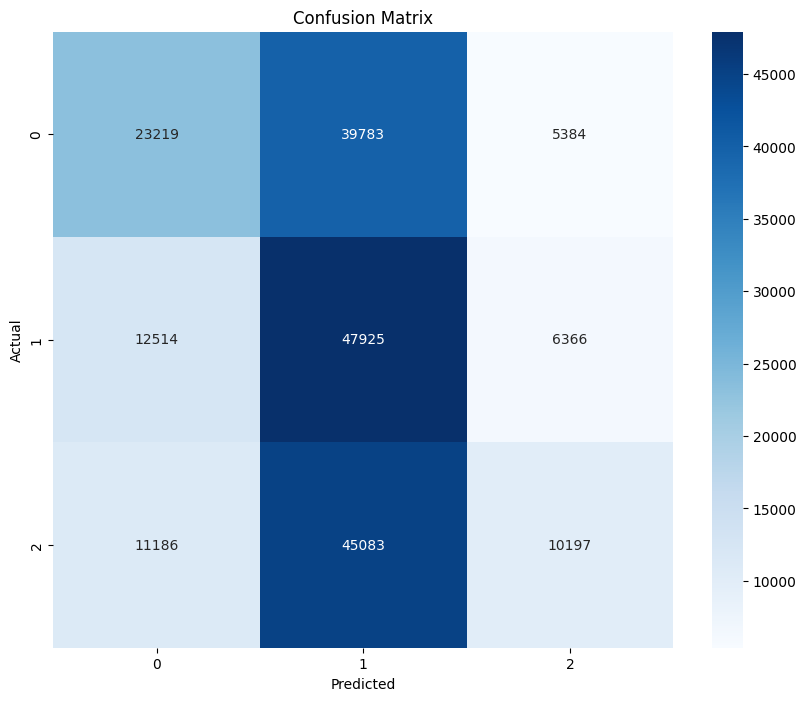

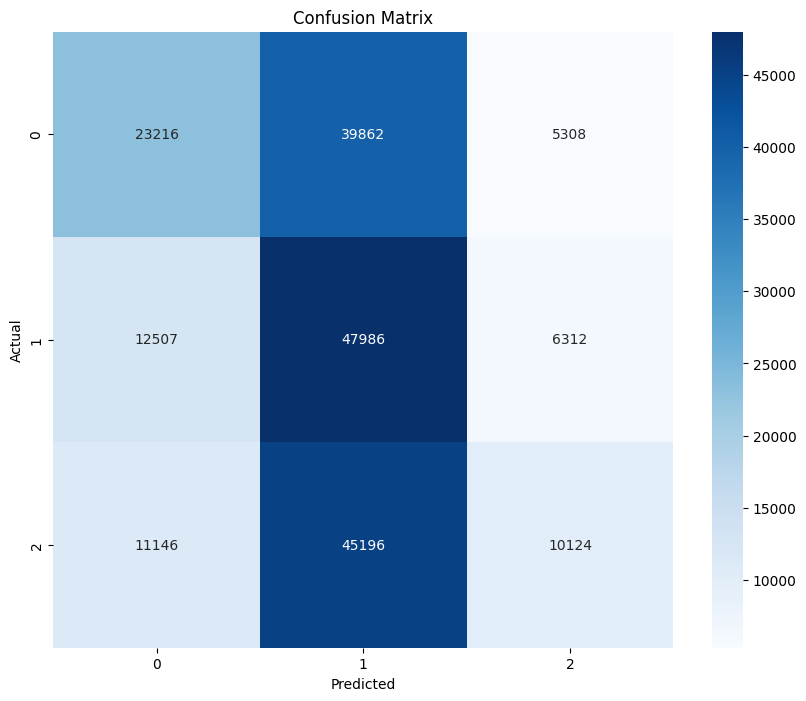

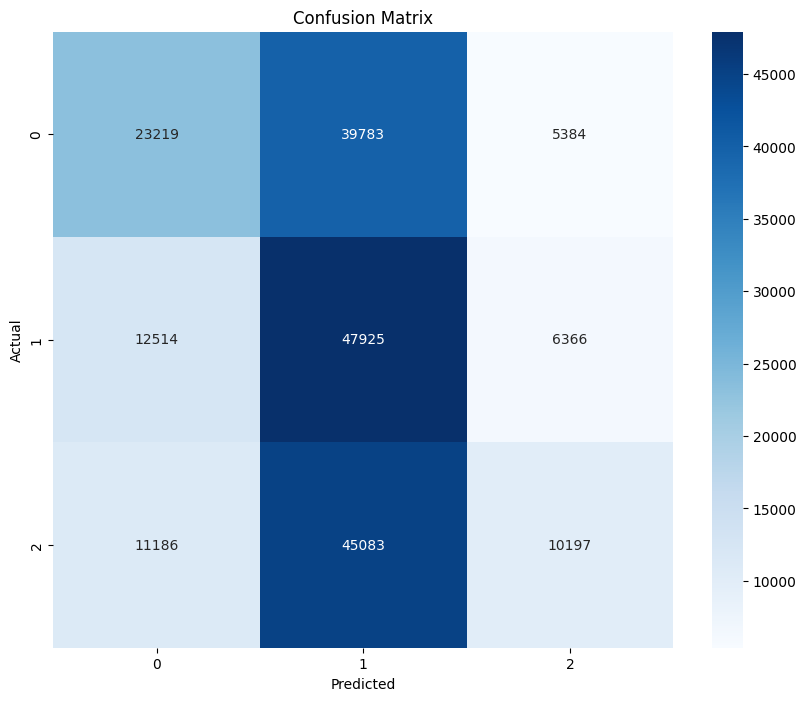

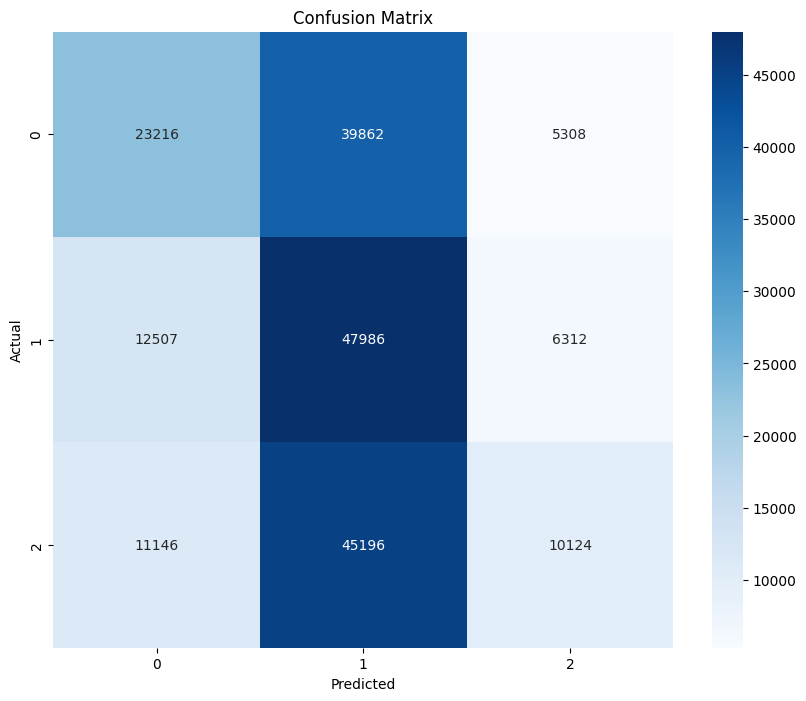

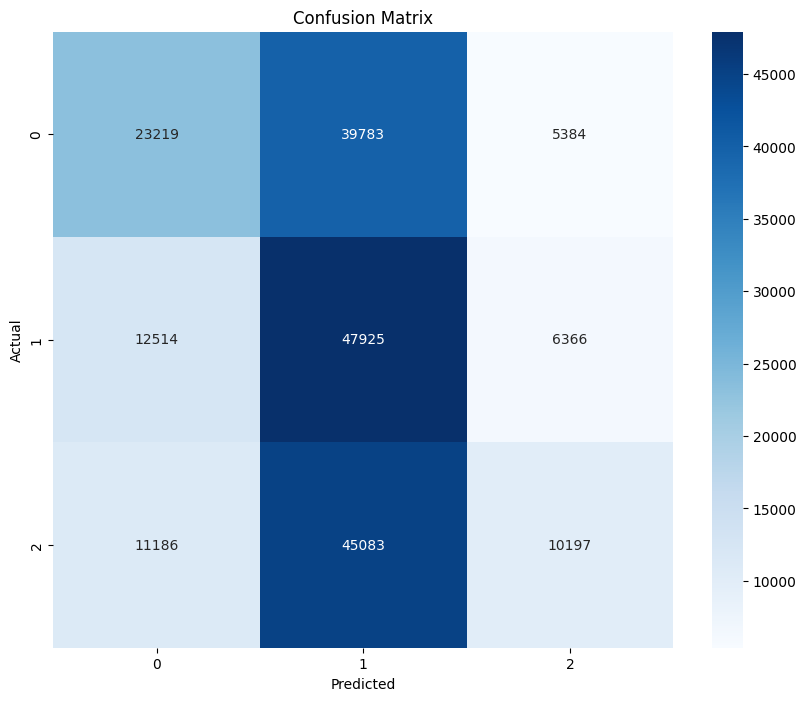

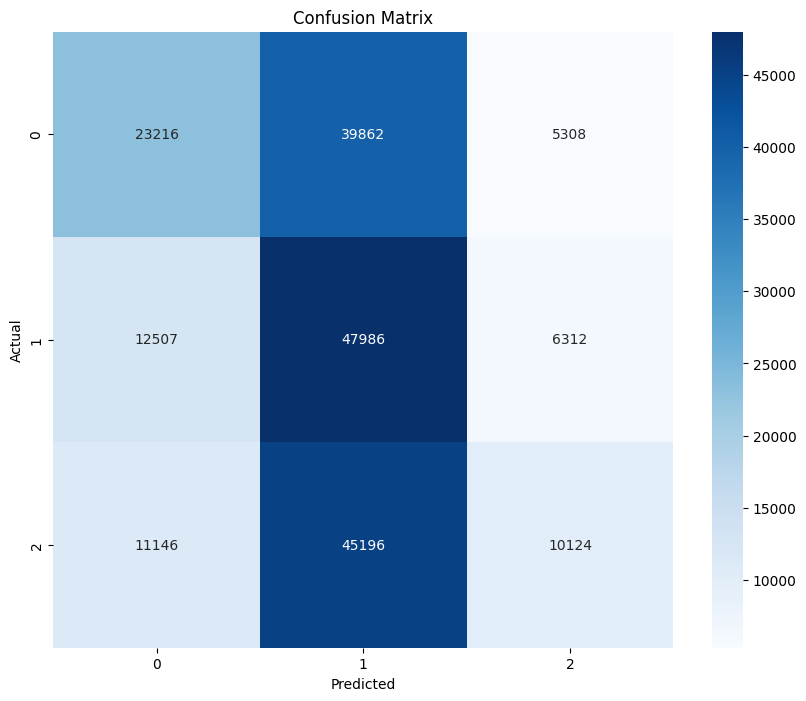

In [7]:
df_path = Path('data/df_preprocessed.csv')
if df_path.exists():
    df = pd.read_csv(df_path)
else:
    print(f"No such file : {df_path}")

max_features = 10
ngrams = [(1,1), (1,2), (1,3)]
methods = ['BoW','TFIDF']
mlflow.set_tracking_uri('http://localhost:5000')
for ngram in ngrams:
    for method in methods:
        run_experiment('Experiment 2: BoW vs TFIDF vectorizers', method, ngram, max_features)

In [ ]:
### Exp3: max_features selection
df_path = Path('data/df_preprocessed.csv')
if df_path.exists():
    df = pd.read_csv(df_path)
else:
    print(f"No such file : {df_path}")

ngram = (1,3) # best from exp2 
method = 'TFIDF' # best from exp2
mlflow.set_tracking_uri('http://localhost:5000')
for max_feats in max_features:
    run_experiment('Experiment 3: Vectorizer max features parameter tuning', method, ngram, max_feats)